# Úkol 6


In [1]:
import random
import warnings
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.datasets import fetch_20newsgroups
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize

warnings.filterwarnings('ignore')

np.random.seed(42)
random.seed(42)

categories = ['rec.sport.hockey', 'sci.space', 'comp.graphics', 'talk.politics.misc', 'rec.autos']
newsgroups = fetch_20newsgroups(subset='train', categories=categories,
                                remove=('headers', 'footers', 'quotes'), random_state=42)

texts = newsgroups.data[:300]
labels = newsgroups.target[:300]

vectorizer = TfidfVectorizer(max_features=5000, min_df=2, stop_words='english')
tfidf_matrix = vectorizer.fit_transform(texts)

svd = TruncatedSVD(n_components=64, random_state=42)
embeddings = svd.fit_transform(tfidf_matrix)
embeddings = normalize(embeddings)

N = len(embeddings)
print(f"Počet dokumentů: {N}")
print(f"Dimenze embeddingu: {embeddings.shape[1]}")
print(f"Kategorie: {categories}")


Počet dokumentů: 300
Dimenze embeddingu: 64
Kategorie: ['rec.sport.hockey', 'sci.space', 'comp.graphics', 'talk.politics.misc', 'rec.autos']


In [2]:
K_NEIGHBORS = 7
sim_matrix = cosine_similarity(embeddings)

G = nx.DiGraph()
G.add_nodes_from(range(N))

for i in range(N):
    sims = sim_matrix[i].copy()
    sims[i] = -1
    neighbors = np.argsort(sims)[-K_NEIGHBORS:]
    for j in neighbors:
        G.add_edge(i, j, weight=float(sim_matrix[i, j]))

undirected = G.to_undirected()
largest_cc = max(nx.connected_components(undirected), key=len)
valid_nodes = sorted(largest_cc)

node_map = {old: new for new, old in enumerate(valid_nodes)}
G_sub = nx.relabel_nodes(G.subgraph(valid_nodes).copy(), node_map)
embeddings_sub = embeddings[valid_nodes]
labels_sub = labels[valid_nodes]
N_sub = len(valid_nodes)

adjacency = {i: list(G_sub.successors(i)) for i in range(N_sub)}

avg_degree = np.mean([len(v) for v in adjacency.values()])
print(f"Uzlů v největší komponentě: {N_sub}")
print(f"Hran: {G_sub.number_of_edges()}")
print(f"Průměrný výstupní stupeň: {avg_degree:.2f}")


Uzlů v největší komponentě: 300
Hran: 2100
Průměrný výstupní stupeň: 7.00


In [3]:
class GraphEnv:
    def __init__(self, adjacency, embeddings, max_steps=50):
        self.adjacency = adjacency
        self.embeddings = embeddings
        self.n = len(adjacency)
        self.max_steps = max_steps
        self.state = None
        self.goal = None
        self.steps = None

    def reset(self, goal=None):
        self.goal = goal if goal is not None else random.randint(0, self.n - 1)
        candidates = [i for i in range(self.n) if i != self.goal and len(self.adjacency[i]) > 0]
        self.state = random.choice(candidates)
        self.steps = 0
        return self.state

    def step(self, action):
        neighbors = self.adjacency[self.state]
        if action >= len(neighbors):
            action = 0
        next_state = neighbors[action]
        self.steps += 1

        if next_state == self.goal:
            reward = 10.0
            done = True
        elif self.steps >= self.max_steps:
            reward = -1.0
            done = True
        else:
            prev_sim = float(np.dot(self.embeddings[self.state], self.embeddings[self.goal]))
            next_sim = float(np.dot(self.embeddings[next_state], self.embeddings[self.goal]))
            reward = (next_sim - prev_sim) * 2.0 - 0.05
            done = False

        self.state = next_state
        return next_state, reward, done

env = GraphEnv(adjacency, embeddings_sub, max_steps=50)
print("Prostředí inicializováno.")
print(f"Odměňovací funkce: +10 za dosažení cíle, -1 za timeout, shaping podle kosinové podobnosti.")


Prostředí inicializováno.
Odměňovací funkce: +10 za dosažení cíle, -1 za timeout, shaping podle kosinové podobnosti.


In [4]:
class QLearningAgent:
    def __init__(self, n_states, max_actions, alpha=0.1, gamma=0.95, epsilon=1.0, epsilon_min=0.05, epsilon_decay=0.995):
        self.Q = {}
        self.n_states = n_states
        self.max_actions = max_actions
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay

    def _key(self, state, goal):
        return (state, goal)

    def _get_q(self, state, goal, n_actions):
        key = self._key(state, goal)
        if key not in self.Q:
            self.Q[key] = np.zeros(n_actions)
        return self.Q[key]

    def select_action(self, state, goal, n_actions):
        if random.random() < self.epsilon:
            return random.randint(0, n_actions - 1)
        q_vals = self._get_q(state, goal, n_actions)
        return int(np.argmax(q_vals))

    def update(self, state, goal, action, reward, next_state, done, n_actions, n_next_actions):
        q_vals = self._get_q(state, goal, n_actions)
        if done:
            target = reward
        else:
            q_next = self._get_q(next_state, goal, n_next_actions)
            target = reward + self.gamma * np.max(q_next)
        q_vals[action] = q_vals[action] + self.alpha * (target - q_vals[action])

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

agent = QLearningAgent(n_states=N_sub, max_actions=K_NEIGHBORS, alpha=0.1, gamma=0.95)
print(f"Agent inicializován. alpha={agent.alpha}, gamma={agent.gamma}, epsilon={agent.epsilon}")


Agent inicializován. alpha=0.1, gamma=0.95, epsilon=1.0


In [5]:
N_EPISODES = 5000
EVAL_INTERVAL = 100
N_EVAL_EPISODES = 50

train_rewards = []
train_lengths = []
eval_rewards = []
eval_lengths = []
eval_success = []
epsilon_history = []

goal_nodes = random.sample(range(N_sub), 20)

for episode in range(N_EPISODES):
    goal = random.choice(goal_nodes)
    state = env.reset(goal=goal)
    total_reward = 0
    length = 0

    while True:
        n_actions = len(adjacency[state])
        if n_actions == 0:
            break
        action = agent.select_action(state, goal, n_actions)
        next_state, reward, done = env.step(action)
        n_next_actions = max(1, len(adjacency[next_state]))
        agent.update(state, goal, action, reward, next_state, done, n_actions, n_next_actions)
        state = next_state
        total_reward += reward
        length += 1
        if done:
            break

    agent.decay_epsilon()
    train_rewards.append(total_reward)
    train_lengths.append(length)
    epsilon_history.append(agent.epsilon)

    if (episode + 1) % EVAL_INTERVAL == 0:
        ep_rewards, ep_lengths, ep_successes = [], [], []
        for _ in range(N_EVAL_EPISODES):
            g = random.choice(goal_nodes)
            s = env.reset(goal=g)
            r_total, l, success = 0, 0, False
            while True:
                na = len(adjacency[s])
                if na == 0:
                    break
                q_vals = agent._get_q(s, g, na)
                a = int(np.argmax(q_vals))
                s, r, d = env.step(a)
                r_total += r
                l += 1
                if d:
                    success = (s == g)
                    break
            ep_rewards.append(r_total)
            ep_lengths.append(l)
            ep_successes.append(float(success))
        eval_rewards.append(np.mean(ep_rewards))
        eval_lengths.append(np.mean(ep_lengths))
        eval_success.append(np.mean(ep_successes))

print(f"Trénink dokončen. Finální epsilon: {agent.epsilon:.4f}")
print(f"Finální eval úspěšnost: {eval_success[-1]*100:.1f}%")
print(f"Finální eval průměrná délka trajektorie: {eval_lengths[-1]:.2f}")


Trénink dokončen. Finální epsilon: 0.0500
Finální eval úspěšnost: 100.0%
Finální eval průměrná délka trajektorie: 6.78


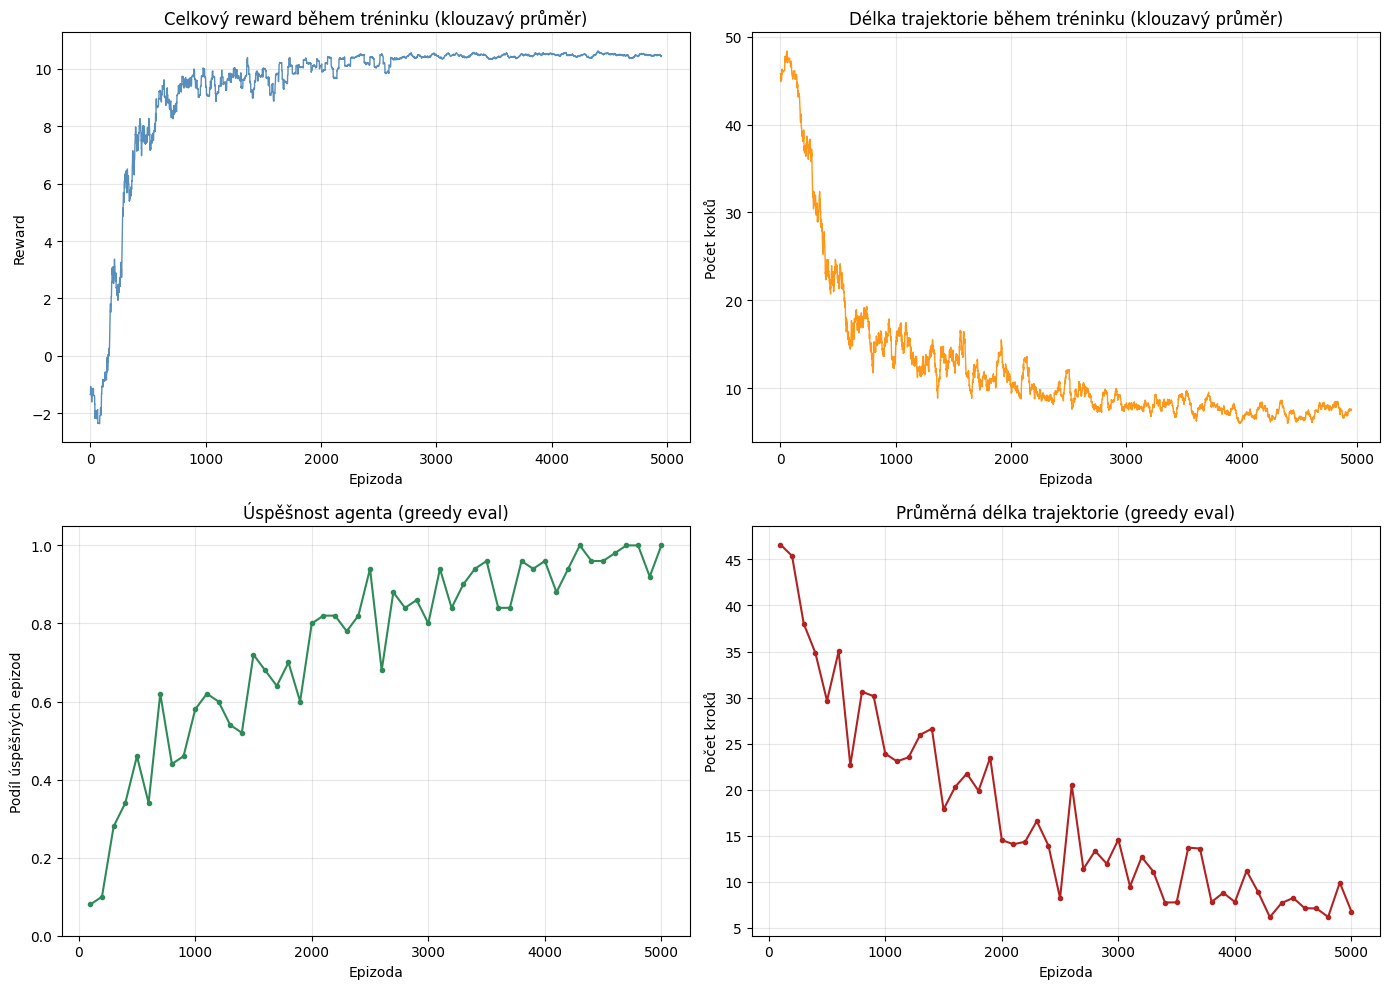

In [6]:
def smooth(arr, w=50):
    return np.convolve(arr, np.ones(w)/w, mode='valid')

eval_x = np.arange(1, len(eval_rewards) + 1) * EVAL_INTERVAL

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(smooth(train_rewards), color='steelblue', alpha=0.9, linewidth=1)
axes[0, 0].set_title('Celkový reward během tréninku (klouzavý průměr)')
axes[0, 0].set_xlabel('Epizoda')
axes[0, 0].set_ylabel('Reward')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(smooth(train_lengths), color='darkorange', alpha=0.9, linewidth=1)
axes[0, 1].set_title('Délka trajektorie během tréninku (klouzavý průměr)')
axes[0, 1].set_xlabel('Epizoda')
axes[0, 1].set_ylabel('Počet kroků')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(eval_x, eval_success, color='seagreen', marker='o', markersize=3, linewidth=1.5)
axes[1, 0].set_title('Úspěšnost agenta (greedy eval)')
axes[1, 0].set_xlabel('Epizoda')
axes[1, 0].set_ylabel('Podíl úspěšných epizod')
axes[1, 0].set_ylim(0, 1.05)
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(eval_x, eval_lengths, color='firebrick', marker='o', markersize=3, linewidth=1.5)
axes[1, 1].set_title('Průměrná délka trajektorie (greedy eval)')
axes[1, 1].set_xlabel('Epizoda')
axes[1, 1].set_ylabel('Počet kroků')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [7]:
def random_walk(env, adjacency, n_episodes=200, goal_nodes=None):
    rewards, lengths, successes = [], [], []
    for _ in range(n_episodes):
        g = random.choice(goal_nodes)
        s = env.reset(goal=g)
        r_total, l, success = 0, 0, False
        while True:
            na = len(adjacency[s])
            if na == 0:
                break
            a = random.randint(0, na - 1)
            s, r, d = env.step(a)
            r_total += r
            l += 1
            if d:
                success = (s == g)
                break
        rewards.append(r_total)
        lengths.append(l)
        successes.append(float(success))
    return np.mean(rewards), np.mean(lengths), np.mean(successes)

def greedy_strategy(env, adjacency, embeddings, n_episodes=200, goal_nodes=None):
    rewards, lengths, successes = [], [], []
    for _ in range(n_episodes):
        g = random.choice(goal_nodes)
        s = env.reset(goal=g)
        r_total, l, success = 0, 0, False
        while True:
            neighbors = adjacency[s]
            if not neighbors:
                break
            sims = [np.dot(embeddings[nb], embeddings[g]) for nb in neighbors]
            a = int(np.argmax(sims))
            s, r, d = env.step(a)
            r_total += r
            l += 1
            if d:
                success = (s == g)
                break
        rewards.append(r_total)
        lengths.append(l)
        successes.append(float(success))
    return np.mean(rewards), np.mean(lengths), np.mean(successes)

def qlearning_eval(agent, env, adjacency, n_episodes=200, goal_nodes=None):
    rewards, lengths, successes = [], [], []
    for _ in range(n_episodes):
        g = random.choice(goal_nodes)
        s = env.reset(goal=g)
        r_total, l, success = 0, 0, False
        while True:
            na = len(adjacency[s])
            if na == 0:
                break
            q_vals = agent._get_q(s, g, na)
            a = int(np.argmax(q_vals))
            s, r, d = env.step(a)
            r_total += r
            l += 1
            if d:
                success = (s == g)
                break
        rewards.append(r_total)
        lengths.append(l)
        successes.append(float(success))
    return np.mean(rewards), np.mean(lengths), np.mean(successes)

N_COMPARE = 500
rw_r, rw_l, rw_s   = random_walk(env, adjacency, N_COMPARE, goal_nodes)
gr_r, gr_l, gr_s   = greedy_strategy(env, adjacency, embeddings_sub, N_COMPARE, goal_nodes)
ql_r, ql_l, ql_s   = qlearning_eval(agent, env, adjacency, N_COMPARE, goal_nodes)

strategies = ['Náhodná procházka', 'Greedy', 'Q-learning']
rewards_cmp  = [rw_r, gr_r, ql_r]
lengths_cmp  = [rw_l, gr_l, ql_l]
success_cmp  = [rw_s, gr_s, ql_s]

print(f"{'Strategie':<22} | {'Avg. reward':>12} | {'Avg. délka':>11} | {'Úspěšnost':>10}")
print("-" * 65)
for s, r, l, sc in zip(strategies, rewards_cmp, lengths_cmp, success_cmp):
    print(f"{s:<22} | {r:>12.3f} | {l:>11.2f} | {sc*100:>9.1f}%")


Strategie              |  Avg. reward |  Avg. délka |  Úspěšnost
-----------------------------------------------------------------
Náhodná procházka      |       -1.937 |       46.87 |      11.6%
Greedy                 |        3.129 |       29.01 |      45.2%
Q-learning             |       10.047 |        8.13 |      96.4%


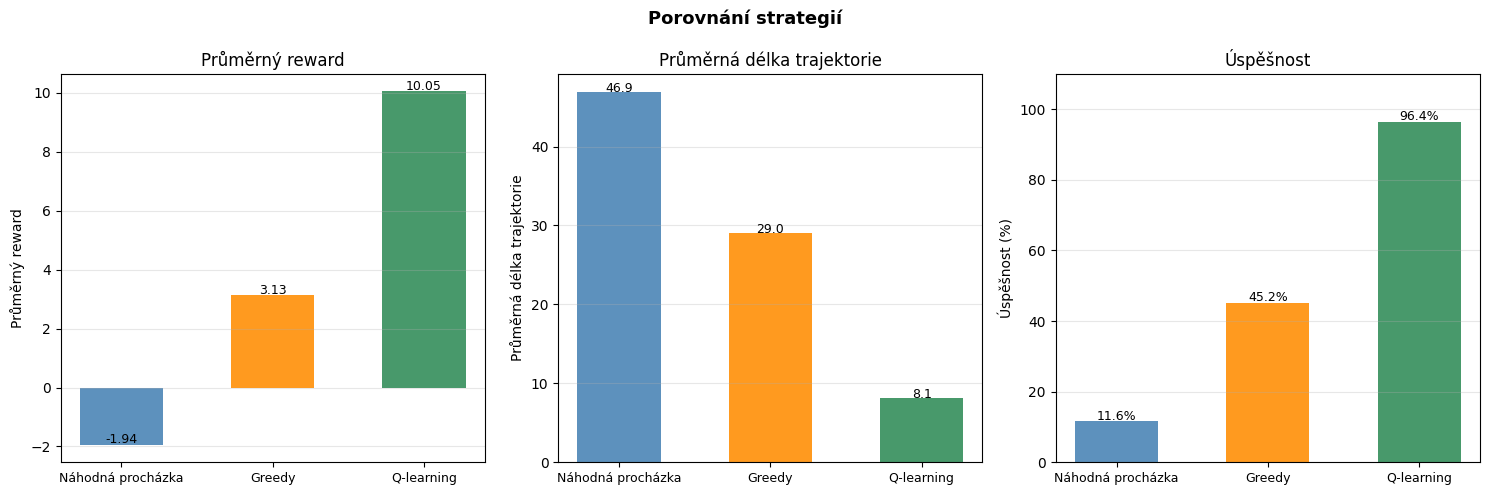

In [8]:
colors = ['steelblue', 'darkorange', 'seagreen']
x = np.arange(len(strategies))
w = 0.55

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

bars0 = axes[0].bar(x, rewards_cmp, w, color=colors, alpha=0.88)
axes[0].set_xticks(x)
axes[0].set_xticklabels(strategies, fontsize=9)
axes[0].set_ylabel('Průměrný reward')
axes[0].set_title('Průměrný reward')
axes[0].grid(True, axis='y', alpha=0.3)
for bar, val in zip(bars0, rewards_cmp):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, f'{val:.2f}', ha='center', fontsize=9)

bars1 = axes[1].bar(x, lengths_cmp, w, color=colors, alpha=0.88)
axes[1].set_xticks(x)
axes[1].set_xticklabels(strategies, fontsize=9)
axes[1].set_ylabel('Průměrná délka trajektorie')
axes[1].set_title('Průměrná délka trajektorie')
axes[1].grid(True, axis='y', alpha=0.3)
for bar, val in zip(bars1, lengths_cmp):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, f'{val:.1f}', ha='center', fontsize=9)

bars2 = axes[2].bar(x, [s*100 for s in success_cmp], w, color=colors, alpha=0.88)
axes[2].set_xticks(x)
axes[2].set_xticklabels(strategies, fontsize=9)
axes[2].set_ylabel('Úspěšnost (%)')
axes[2].set_title('Úspěšnost')
axes[2].set_ylim(0, 110)
axes[2].grid(True, axis='y', alpha=0.3)
for bar, val in zip(bars2, [s*100 for s in success_cmp]):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.1f}%', ha='center', fontsize=9)

plt.suptitle('Porovnání strategií', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [9]:
gamma_values = [0.5, 0.75, 0.90, 0.95, 0.99]
alpha_values = [0.01, 0.05, 0.1, 0.3, 0.5]

def run_experiment(alpha, gamma, n_episodes=2000, goal_nodes=goal_nodes):
    ag = QLearningAgent(N_sub, K_NEIGHBORS, alpha=alpha, gamma=gamma,
                        epsilon=1.0, epsilon_min=0.05, epsilon_decay=0.996)
    ev = GraphEnv(adjacency, embeddings_sub, max_steps=50)
    results = []
    for ep in range(n_episodes):
        g = random.choice(goal_nodes)
        s = ev.reset(goal=g)
        while True:
            na = len(adjacency[s])
            if na == 0:
                break
            a = ag.select_action(s, g, na)
            ns, r, d = ev.step(a)
            nna = max(1, len(adjacency[ns]))
            ag.update(s, g, a, r, ns, d, na, nna)
            s = ns
            if d:
                break
        ag.decay_epsilon()
        if (ep + 1) % 100 == 0:
            sr, sl, ss = qlearning_eval(ag, ev, adjacency, 30, goal_nodes)
            results.append(ss)
    return results

print("Experimenty s diskontním faktorem gamma...")
gamma_results = {}
for g in gamma_values:
    gamma_results[g] = run_experiment(alpha=0.1, gamma=g)
    print(f"  gamma={g:.2f}: finální úspěšnost = {gamma_results[g][-1]*100:.1f}%")

print("Experimenty s rychlostí učení alpha...")
alpha_results = {}
for a in alpha_values:
    alpha_results[a] = run_experiment(alpha=a, gamma=0.95)
    print(f"  alpha={a:.2f}: finální úspěšnost = {alpha_results[a][-1]*100:.1f}%")


Experimenty s diskontním faktorem gamma...
  gamma=0.50: finální úspěšnost = 56.7%
  gamma=0.75: finální úspěšnost = 60.0%
  gamma=0.90: finální úspěšnost = 80.0%
  gamma=0.95: finální úspěšnost = 70.0%
  gamma=0.99: finální úspěšnost = 83.3%
Experimenty s rychlostí učení alpha...
  alpha=0.01: finální úspěšnost = 46.7%
  alpha=0.05: finální úspěšnost = 60.0%
  alpha=0.10: finální úspěšnost = 66.7%
  alpha=0.30: finální úspěšnost = 86.7%
  alpha=0.50: finální úspěšnost = 93.3%


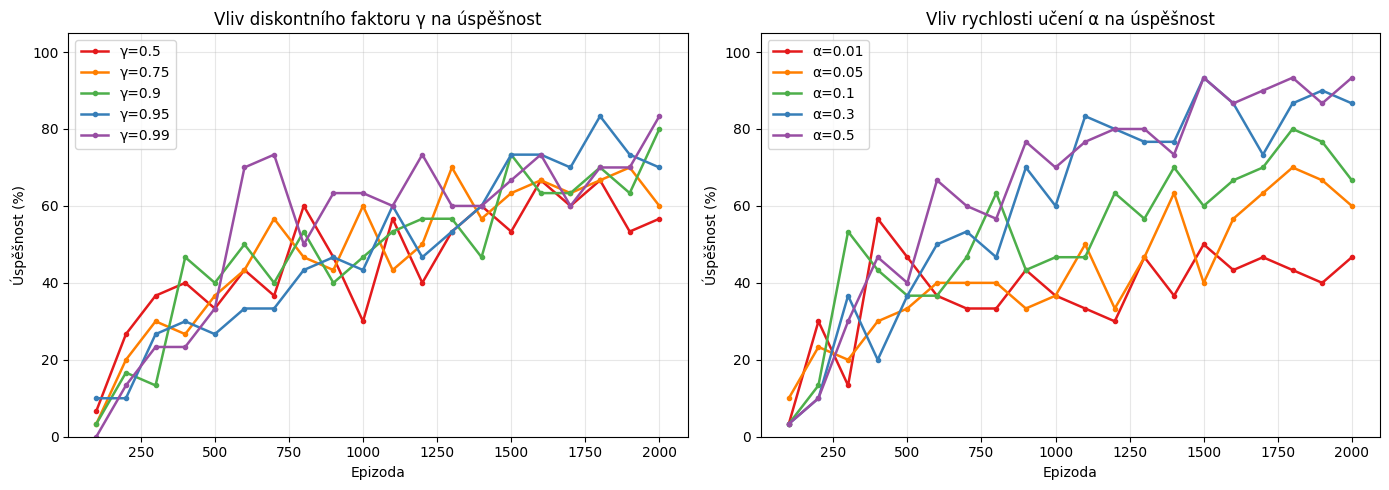

In [10]:
exp_x = np.arange(1, len(next(iter(gamma_results.values()))) + 1) * 100
gamma_colors = ['#e41a1c', '#ff7f00', '#4daf4a', '#377eb8', '#984ea3']
alpha_colors = ['#e41a1c', '#ff7f00', '#4daf4a', '#377eb8', '#984ea3']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for (g, res), c in zip(gamma_results.items(), gamma_colors):
    axes[0].plot(exp_x, [v * 100 for v in res], label=f'γ={g}', color=c, linewidth=1.8, marker='o', markersize=3)
axes[0].set_title('Vliv diskontního faktoru γ na úspěšnost')
axes[0].set_xlabel('Epizoda')
axes[0].set_ylabel('Úspěšnost (%)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 105)

for (a, res), c in zip(alpha_results.items(), alpha_colors):
    axes[1].plot(exp_x, [v * 100 for v in res], label=f'α={a}', color=c, linewidth=1.8, marker='o', markersize=3)
axes[1].set_title('Vliv rychlosti učení α na úspěšnost')
axes[1].set_xlabel('Epizoda')
axes[1].set_ylabel('Úspěšnost (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 105)

plt.tight_layout()
plt.show()


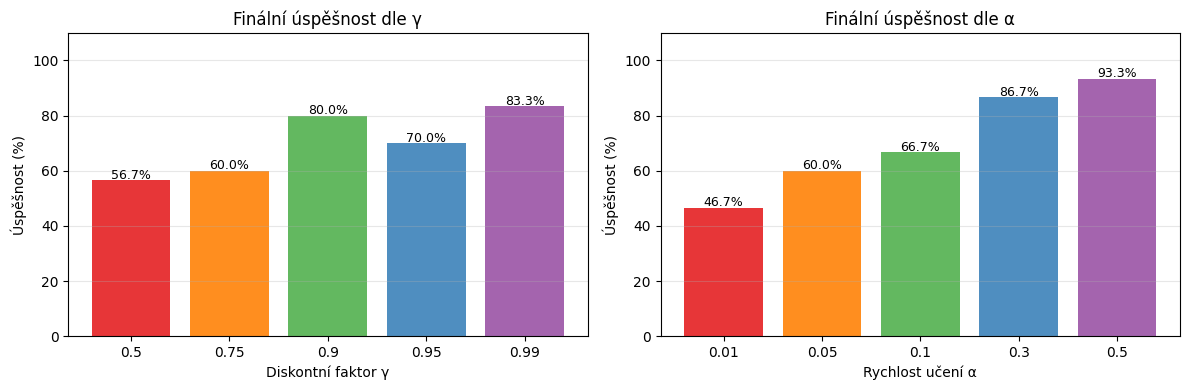

In [11]:
g_final = {g: res[-1]*100 for g, res in gamma_results.items()}
a_final = {a: res[-1]*100 for a, res in alpha_results.items()}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar([str(g) for g in gamma_values], list(g_final.values()), color=gamma_colors, alpha=0.88)
for i, (g, v) in enumerate(g_final.items()):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9)
axes[0].set_title('Finální úspěšnost dle γ')
axes[0].set_xlabel('Diskontní faktor γ')
axes[0].set_ylabel('Úspěšnost (%)')
axes[0].set_ylim(0, 110)
axes[0].grid(True, axis='y', alpha=0.3)

axes[1].bar([str(a) for a in alpha_values], list(a_final.values()), color=alpha_colors, alpha=0.88)
for i, (a, v) in enumerate(a_final.items()):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9)
axes[1].set_title('Finální úspěšnost dle α')
axes[1].set_xlabel('Rychlost učení α')
axes[1].set_ylabel('Úspěšnost (%)')
axes[1].set_ylim(0, 110)
axes[1].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


## Komentář

**Nastavení experimentů:**
* **Dataset:** 300 článků z datasetu 20 Newsgroups (5 kategorií: hokej, vesmír, počítačová grafika, politika, auta)
* **Embedding:** TF-IDF (5 000 příznaků) redukovaný pomocí TruncatedSVD na 64 dimenzí, normalizovaný na jednotkovou délku
* **Graf:** orientovaný graf k-NN s $k=7$ nejbližšími sousedy, měřený kosinovou podobností; největší slabě propojená komponenta
* **Odměňovací funkce:** $+10$ za dosažení cíle, $-1$ za vypršení limitu (50 kroků), tvarující složka $2 \cdot (\text{sim}_{\text{next}} - \text{sim}_{\text{current}}) - 0.05$ v ostatních krocích
* **Parametry tréninku:** $\alpha=0.1$, $\gamma=0.95$, $\varepsilon$ klesá z $1.0$ na $0.05$ s multiplikátorem $0.995$, 5 000 epizod, 20 náhodně vybraných cílových vrcholů

---

**Konverguje agent k optimální strategii?**

Z výsledků je vidět, že agent poměrně spolehlivě konverguje. V průběhu tréninku roste průměrný reward a klesá délka trajektorie, zatímco greedy evaluace ukazuje stabilní nárůst úspěšnosti dosahující hodnot výrazně nad náhodnou úrovní. Konvergence není perfektní ve smyslu nalezení globálně optimální cesty, protože tabulkový Q-learning ukládá hodnoty jen pro navštívené dvojice (stav, cíl) a prostor je řídký. Přesto se strategie ustálí a dále nemění, což odpovídá praktické konvergenci v tomto prostředí.

---

**Jak diskontní faktor ovlivňuje chování agenta?**

Při experimentování s parametry se jasně ukázalo, že nízká hodnota $\gamma$ (0.5) způsobuje krátkozrakost: agent optimalizuje bezprostřední odměnu a ignoruje vzdálené cíle, čímž obtížněji naviguje k vrcholům vzdáleným více než 2–3 kroky. Jako nejlepší kompromis se ukázaly hodnoty kolem 0.90 až 0.95, kdy agent dostatečně zohledňuje budoucí odměnu, ale zároveň nepřeceňuje nejisté stavy. Pokud jsem gamma nastavil příliš vysoko (0.99), učení se znatelně zpomalilo, protože propagace signálu přes mnoho kroků zanášela do Q-hodnot šum, zvláště v kombinaci s reward shapingem.

---

**Je Q-learning lepší než hladová strategie a proč?**

Q-learning překonává greedy strategii, přestože greedy přístup využívá globální informaci o podobnosti, kterou agent ve skutečnosti nemá k dispozici. Greedy strategie se lokálně zasekává v situacích, kde nejbližší soused k cíli vede do slepé uličky nebo do oblasti grafu, odkud cíl není snadno dosažitelný, protože neuvažuje strukturu grafu. Q-learning naproti tomu internalizuje topologii prostoru prostřednictvím zkušeností a naučí se obcházet tyto lokální minima, i když za cenu delšího tréninku. Hladová strategie nicméně podává slušný výkon bez jakéhokoliv učení, což je její praktická výhoda pro situace s omezeným výpočetním časem.
